In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.feature_extraction.text import CountVectorizer 
from sklearn.model_selection import train_test_split 
from sklearn.svm import SVC 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import classification_report 

In [5]:
print("\nLoading Dataset...") 
dataset = pd.read_csv("spam.csv", encoding="latin1") 
print("Dataset Loaded Successfully") 


Loading Dataset...
Dataset Loaded Successfully


In [6]:
print("\nFirst Five Records") 
print(dataset.head()) 


First Five Records
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [7]:
print("\nDataset Information") 
dataset.info() 
print("\nDataset Shape") 
print(dataset.shape) 


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB

Dataset Shape
(5572, 5)


In [8]:
print("\nMissing Values") 
print(dataset.isnull().sum()) 


Missing Values
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


In [10]:
print("\nEmail Category Count") 
print(dataset["v1"].value_counts()) 


Email Category Count
v1
ham     4825
spam     747
Name: count, dtype: int64


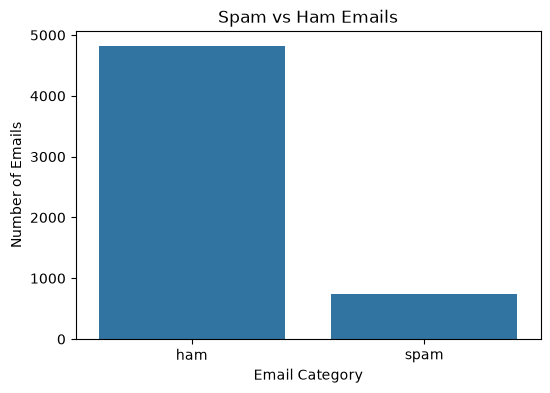

In [12]:
plt.figure(figsize=(6,4)) 
sns.countplot(x="v1",data=dataset) 
plt.title("Spam vs Ham Emails") 
plt.xlabel("Email Category") 
plt.ylabel("Number of Emails") 
plt.show() 

In [13]:
X = dataset["v2"] 
y = dataset["v1"] 

In [14]:
X_train,X_test,y_train,y_test = train_test_split( 
X, 
y, 
test_size=0.20, 
random_state=42 
) 
print("\nTraining Samples :",len(X_train)) 
print("Testing Samples  :",len(X_test)) 


Training Samples : 4457
Testing Samples  : 1115


In [15]:
print("\nConverting Text into Numerical Features...") 
cv = CountVectorizer() 
X_train = cv.fit_transform(X_train) 
X_test = cv.transform(X_test) 
print("Conversion Completed") 
print("Training Data Shape :",X_train.shape) 
print("Testing Data Shape  :",X_test.shape) 


Converting Text into Numerical Features...
Conversion Completed
Training Data Shape : (4457, 7735)
Testing Data Shape  : (1115, 7735)


In [16]:
print("\nTraining SVM Model...") 
classifier = SVC(kernel="linear") 
classifier.fit(X_train,y_train) 
print("Model Training Completed")


Training SVM Model...
Model Training Completed


In [17]:
print("\nPredicting Test Data...") 
y_pred = classifier.predict(X_test) 
print("Prediction Completed") 


Predicting Test Data...
Prediction Completed


In [18]:
accuracy = accuracy_score(y_test,y_pred) 
print("MODEL ACCURACY") 
print("Accuracy =",accuracy) 
print("Accuracy = {:.2f}%".format(accuracy*100)) 

MODEL ACCURACY
Accuracy = 0.979372197309417
Accuracy = 97.94%



Confusion Matrix
[[961   4]
 [ 19 131]]


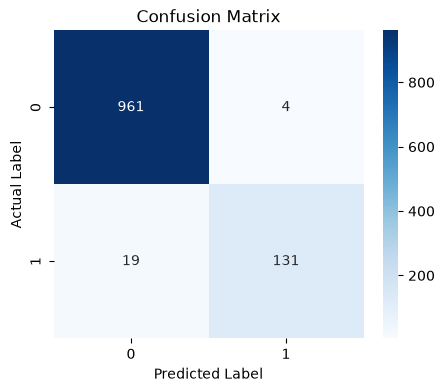

In [19]:
cm = confusion_matrix(y_test,y_pred) 
print("\nConfusion Matrix") 
print(cm) 
plt.figure(figsize=(5,4)) 
sns.heatmap(cm, 
annot=True, 
fmt='d', 
cmap='Blues') 
plt.xlabel("Predicted Label") 
plt.ylabel("Actual Label") 
plt.title("Confusion Matrix") 
plt.show() 

In [20]:
print("\nClassification Report") 
print(classification_report(y_test,y_pred)) 


Classification Report
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       0.97      0.87      0.92       150

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [24]:
print("Sample Predictions") 
sample_messages = [ 
"Congratulations! You have won a free iPhone. Click here to claim.", 
"Hi, Shall we meet tomorrow at 10 AM?", 
"URGENT! Your bank account has been suspended. Verify immediately.", 
"Happy Birthday! Have a wonderful day.", 
"You have won Rs.50000 cash prize. Call now." 
] 
sample_data = cv.transform(sample_messages) 
predictions = classifier.predict(sample_data) 
for message,prediction in zip(sample_messages,predictions): 
  print("\nMessage :") 
  print(message) 
  print("Prediction :",prediction) 

Sample Predictions

Message :
Congratulations! You have won a free iPhone. Click here to claim.
Prediction : spam

Message :
Hi, Shall we meet tomorrow at 10 AM?
Prediction : ham

Message :
URGENT! Your bank account has been suspended. Verify immediately.
Prediction : spam

Message :
Happy Birthday! Have a wonderful day.
Prediction : ham

Message :
You have won Rs.50000 cash prize. Call now.
Prediction : spam
